In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from preprocess import load_and_clean

In [34]:
DATA_PATH = "../../clean_data/Model_Ready.csv"

OUTPUT_PATH = "./outputs/"

In [44]:
df_full, df_model_ready = load_and_clean(
    "../../clean_data/Model_Ready.csv"
)

x = [c for c in df_full.columns if "unemployment" in c] 
print(x)
print(
    "Full dataset:",
    df_full.shape
)

print(
    "Model dataset:",
    df_model_ready.shape
)

print(
    df_model_ready["month"].min()
)

print(
    df_model_ready["month"].max()
)


['unemployment_rate_lag1']
Full dataset: (138, 22)
Model dataset: (89, 22)
2019-02-01 00:00:00
2026-06-01 00:00:00


In [45]:
target = "total_people_served"


features = [

    # Time
    "year",
    "month_num",

    # Demand history
    "total_people_served_lag1",
    "total_people_served_lag2",
    "total_people_served_lag3",
    "total_people_served_lag6",
    "total_people_served_lag12",

    # Rolling demand
    "total_people_served_rollingavg3",
    "total_people_served_rollingavg6",
    "total_people_served_rollingavg12",

    # OW
    "ow_cases_official_lag1",
    "ow_beneficiaries_lag1",

    # ODSP
    "odsp_cases_official_lag1",
    "odsp_beneficiaries_lag1",

    # Homelessness
    "total_homeless_lag1",
    "total_chronic_homeless_lag1",

    # CPI
    "cpi_all_items_lag1",
    "cpi_food_lag1",
    "cpi_shelter_lag1",

    # Labour
    "unemployment_rate_lag1"
]

In [46]:
def train_regression_model(
    train_start,
    train_end
):

    train = df_model_ready[
        (df_model_ready["month"] >= train_start)
        &
        (df_model_ready["month"] <= train_end)
    ]


    test = df_model_ready[
        df_model_ready["month"] > train_end
    ]


    X_train = train[features]
    y_train = train[target]


    X_test = test[features]
    y_test = test[target]


    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(alpha=1)
        )
    ])


    model.fit(
        X_train,
        y_train
    )


    predictions = model.predict(
        X_test
    )


    return (
        model,
        test["month"],
        y_test,
        predictions
    )

In [47]:
def evaluate_model(
    y_true,
    y_pred
):

    results = {

        "MAE":
        mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE":
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "WAPE":
        np.sum(
            abs(y_true-y_pred)
        )
        /
        np.sum(
            abs(y_true)
        ),

        "R2":
        r2_score(
            y_true,
            y_pred
        )
    }


    return pd.Series(results)

In [58]:
#### Train Model 1

model_2019, month_2019, y_test_2019, pred_2019 = train_regression_model(
    "2019-02-01",
    "2025-06-01"
)

metrics_2019 = evaluate_model(
    y_test_2019,
    pred_2019
)

metrics_2019

MAE     2755.354570
RMSE    3266.265856
WAPE       0.049297
R2        -0.182103
dtype: float64

In [59]:
model_2022, month_2022, y_test_2022, pred_2022 = train_regression_model(
    "2022-01-01",
    "2025-06-01"
)
metrics_2022 = evaluate_model(
    y_test_2022,
    pred_2022
)

metrics_2022

MAE     4028.049372
RMSE    5142.209755
WAPE       0.072067
R2        -1.929893
dtype: float64

In [60]:
comparison = pd.DataFrame(
    {
        "2019-2025 Training": metrics_2019,
        "2022-2025 Training": metrics_2022
    }
)

comparison

,2019-2025 Training,2022-2025 Training
MAE,2755.354570,4028.049372
RMSE,3266.265856,5142.209755
WAPE,0.049297,0.072067
R2,-0.182103,-1.929893


In [61]:
def plot_forecast(
    months,
    actual,
    predicted,
    title
):

    plt.figure(figsize=(12,5))


    plt.plot(
        months,
        actual,
        label="Actual"
    )


    plt.plot(
        months,
        predicted,
        label="Predicted"
    )


    plt.title(title)

    plt.xlabel("Month")

    plt.ylabel(
        "People Served"
    )

    plt.legend()

    plt.xticks(rotation=45)

    plt.show()

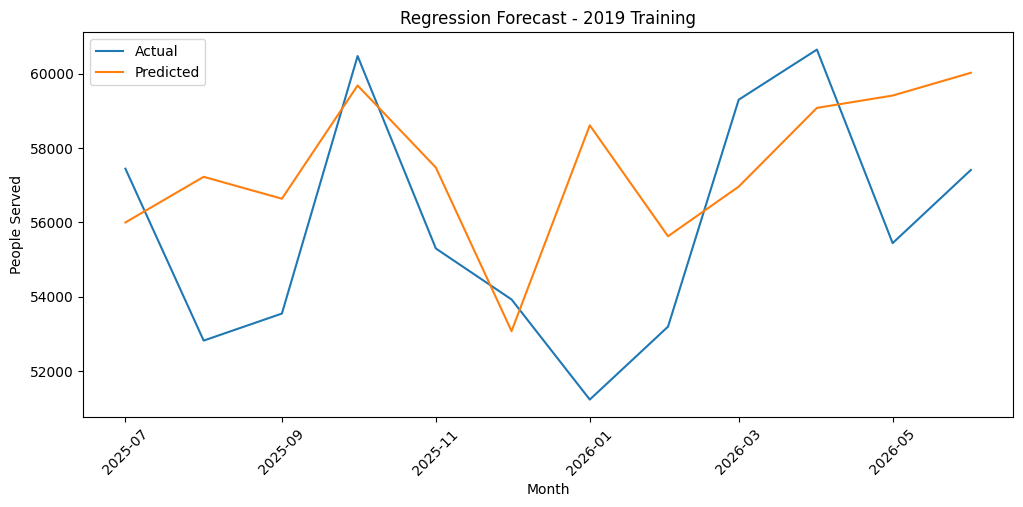

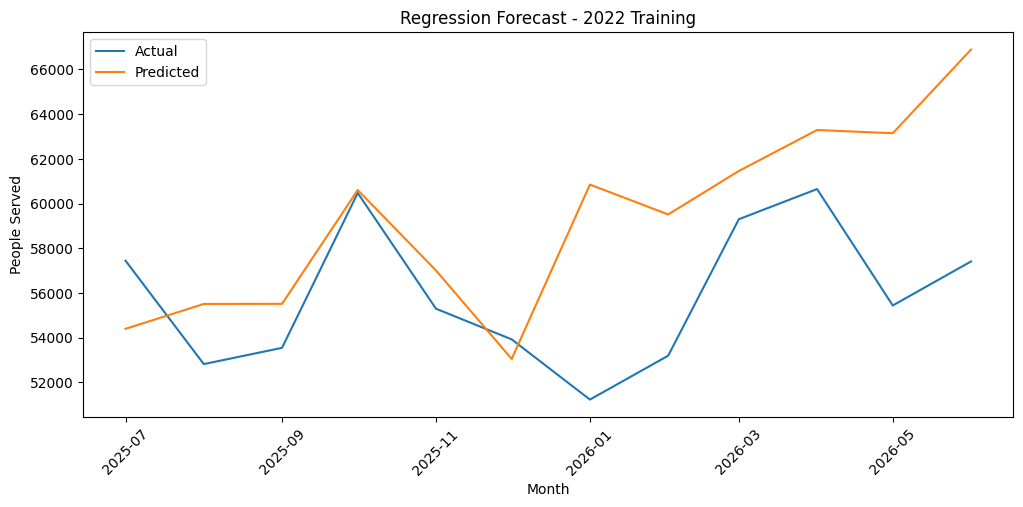

In [52]:
plot_forecast(
    month_2019,
    y_test_2019,
    pred_2019,
    "Regression Forecast - 2019 Training"
)

plot_forecast(
    month_2022,
    y_test_2022,
    pred_2022,
    "Regression Forecast - 2022 Training"
)


In [62]:
ridge = model_2019.named_steps["ridge"]


importance = pd.DataFrame(
    {
        "Feature":features,
        "Coefficient":ridge.coef_
    }
)


importance["Absolute Importance"] = (
    importance["Coefficient"].abs()
)


importance = importance.sort_values(
    "Absolute Importance",
    ascending=False
)


importance

,Feature,Coefficient,Absolute Importance
6,total_people_served_lag12,4819.078874,4819.078874
17,cpi_food_lag1,2808.299167,2808.299167
3,total_people_served_lag2,1776.146286,1776.146286
9,total_people_served_rollingavg12,-1724.787060,1724.787060
5,total_people_served_lag6,1646.245600,1646.245600
15,total_chronic_homeless_lag1,1618.634057,1618.634057
10,ow_cases_official_lag1,-1304.780411,1304.780411
18,cpi_shelter_lag1,-1245.291574,1245.291574
12,odsp_cases_official_lag1,-1208.648963,1208.648963
7,total_people_served_rollingavg3,1190.025894,1190.025894


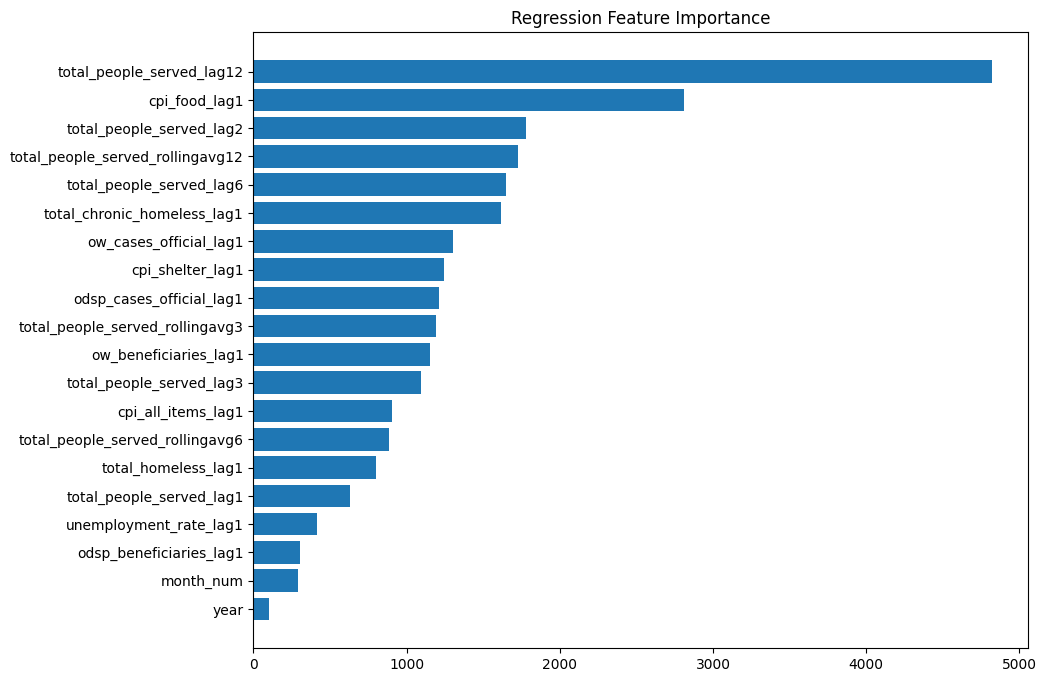

In [63]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Absolute Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Regression Feature Importance"
)

plt.show()

In [64]:
comparison.to_csv(
    "outputs/regression_metrics.csv"
)
pd.DataFrame({
    "month":month_2019,
    "actual":y_test_2019,
    "predicted":pred_2019
}).to_csv(
    "outputs/predictions_2019.csv",
    index=False
)
pd.DataFrame({
    "month":month_2022,
    "actual":y_test_2022,
    "predicted":pred_2022
}).to_csv(
    "outputs/predictions_2022.csv",
    index=False
)

In [66]:
results_table = pd.DataFrame(
    [
        {
            "Model": "Ridge Regression",
            "Train Period": "2019-01 to 2025-06",
            "Train Months": len(
                df_model_ready[
                    (df_model_ready["month"] >= "2019-01-01") &
                    (df_model_ready["month"] <= "2025-06-01")
                ]
            ),
            "Test Period": "2025-07 onwards",
            "MAE": metrics_2019["MAE"],
            "RMSE": metrics_2019["RMSE"],
            "WAPE %": metrics_2019["WAPE"] * 100,
            "R²": metrics_2019["R2"],
            "Bias": np.mean(
                pred_2019 - y_test_2019
            )
        },

        {
            "Model": "Ridge Regression",
            "Train Period": "2022-01 to 2025-06",
            "Train Months": len(
                df_model_ready[
                    (df_model_ready["month"] >= "2022-01-01") &
                    (df_model_ready["month"] <= "2025-06-01")
                ]
            ),
            "Test Period": "2025-07 onwards",
            "MAE": metrics_2022["MAE"],
            "RMSE": metrics_2022["RMSE"],
            "WAPE %": metrics_2022["WAPE"] * 100,
            "R²": metrics_2022["R2"],
            "Bias": np.mean(
                pred_2022 - y_test_2022
            )
        }
    ]
)

print(results_table)

              Model        Train Period  Train Months      Test Period  \
0  Ridge Regression  2019-01 to 2025-06            77  2025-07 onwards   
1  Ridge Regression  2022-01 to 2025-06            42  2025-07 onwards   

           MAE         RMSE    WAPE %        R²         Bias  
0  2755.354570  3266.265856  4.929695 -0.182103  1589.229849  
1  4028.049372  5142.209755  7.206715 -1.929893  3374.602793  
